In [26]:
!pip -q install optuna

In [27]:
!pip -q install mlflow

In [28]:
!pip install seaborn

## 🔧 Cellule — Setup, environnement, dépendances et chemins

**But :** préparer un notebook *portable* (Kaggle / Colab / local) et sécuriser l’exécution du pipeline ML.

### 1) Imports & bases
- Active `from __future__ import annotations` .
- Importe les libs standards (OS, temps, GC, Path…) + data (`numpy`, `pandas`) + ML (`sklearn`) + viz (`seaborn`, `matplotlib`).

### 2) Détection d’environnement (Kaggle / Colab / local)
- `IS_KAGGLE` : vrai si `/kaggle/input` existe ou si la variable d’environnement Kaggle est présente.
- `IS_COLAB` : vrai si `google.colab` est importable.
➡️ Objectif : adapter automatiquement chemins et installation de dépendances selon où tu exécutes.

### 3) Colab : montage du Drive
- Si `IS_COLAB`, monte Google Drive (`/content/drive`) pour accéder à tes fichiers persistants.
➡️ Utile si tes données/modèles sont stockés sur Drive.

### 4) Installation “sans terminal” (optionnel)
- Fonction `_pip_install_if_needed(pkg)` :
  - tente d’importer le package
  - sinon lance `pip install` via `subprocess`
➡️ Objectif : éviter d’aller au terminal (pratique dans un notebook).

- Sur Colab : installe toujours `lightgbm` et `mlflow` si manquants.
- En local : tente d’importer LightGBM, et auto-installe si nécessaire (sauf sur Kaggle/Colab).

### 5) Vérification LightGBM
- Tente `from lightgbm import LGBMClassifier, early_stopping, log_evaluation`
- Si échec : stocke l’erreur puis retente une installation (selon l’environnement).
- Si toujours absent : lève un `ModuleNotFoundError` explicite.
➡️ Objectif : fail-fast avec un message clair.

### 6) Chemins d’entrée/sortie
- Définit `INPUT_DIR` et `OUTPUT_DIR` (ici en chemins Windows).
- Crée automatiquement `OUTPUT_DIR`.
➡️ Objectif : centraliser où lire les CSV et où écrire les outputs (submission, logs, artefacts).

> ⚠️ Note : pour Kaggle, les chemins seront plutôt du type `/kaggle/input/...` et `/kaggle/working/...`.

### 7) MLflow (optionnel, avec fallback “no-op”)
- Définit une implémentation `_NoOpMLflow` si MLflow n’est pas dispo.
- Si MLflow est importable :
  - configure un tracking local en `file:` dans `OUTPUT_DIR/mlruns`
  - fixe l’experiment `Home_Credit_Risk`
➡️ Objectif : tracer paramètres/métriques/artefacts *sans casser* l’exécution si MLflow n’est pas installé.

### 8) Confort d’affichage + sanity checks
- Ajuste options pandas (max colonnes, largeur).
- Affiche un récapitulatif :
  - environnement détecté
  - disponibilité LightGBM
  - chemins input/output
  - activation MLflow

✅ **Sortie attendue :** la cellule confirme que tout est prêt avant de charger les données et lancer le pipeline.


In [29]:
# ==========================================================
# 0) Imports + environment paths + optional MLflow
# ==========================================================

from __future__ import annotations

import os
import time
import gc
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
from pathlib import Path


# ------------------------------
# Detect environment (Colab / Kaggle / local)
# ------------------------------
IS_KAGGLE = Path("/kaggle/input").exists() or bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
try:
    import google.colab  # type: ignore
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# ------------------------------
# Colab: mount Google Drive (needed for /content/drive/... paths)
# ------------------------------
if IS_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")

# ------------------------------
# Optional: install deps (to avoid using the terminal)
# ------------------------------
def _pip_install_if_needed(pkg: str) -> None:
    try:
        __import__(pkg.split("==")[0].split(">=")[0].split("[")[0])
        return
    except Exception:
        pass
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Colab: always install missing deps
if IS_COLAB:
    _pip_install_if_needed("lightgbm")
    _pip_install_if_needed("mlflow")

# Local: try import, and auto-install if missing (no terminal needed)
LIGHTGBM_AVAILABLE = False
_lgb_import_error = None
try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    _lgb_import_error = str(e)
    if not IS_KAGGLE and not IS_COLAB:
        try:
            _pip_install_if_needed("lightgbm")
            from lightgbm import LGBMClassifier, early_stopping, log_evaluation
            LIGHTGBM_AVAILABLE = True
        except Exception as e2:
            _lgb_import_error = str(e2)

if not LIGHTGBM_AVAILABLE:
    raise ModuleNotFoundError(
        "LightGBM is required but not installed. "
        "Install it (e.g. pip install lightgbm) and rerun this cell. "
        f"Import error: {_lgb_import_error}"
    )

# ------------------------------
# Paths (Kaggle-compatible)
# ------------------------------

    # Colab Drive layout (as requested)
INPUT_DIR = Path("/content/drive/MyDrive/Credit/datasets/data/raw")
OUTPUT_DIR = Path("/content/drive/MyDrive/Credit/outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# ------------------------------
# Optional MLflow (fallback no-op)
# ------------------------------
class _NoOpRun:
    def __enter__(self):
        return self
    def __exit__(self, exc_type, exc, tb):
        return False

class _NoOpMLflow:
    def set_tracking_uri(self, *args, **kwargs):
        pass
    def set_experiment(self, *args, **kwargs):
        pass
    def start_run(self, *args, **kwargs):
        return _NoOpRun()
    def log_params(self, *args, **kwargs):
        pass
    def log_param(self, *args, **kwargs):
        pass
    def log_metric(self, *args, **kwargs):
        pass
    def log_artifact(self, *args, **kwargs):
        pass

try:
    import mlflow as _mlflow
    mlruns_dir = (OUTPUT_DIR / "mlruns")
    mlruns_dir.mkdir(parents=True, exist_ok=True)
    _mlflow.set_tracking_uri(f"file:{mlruns_dir.resolve().as_posix()}")
    _mlflow.set_experiment("Home_Credit_Risk")
    mlflow = _mlflow
    MLFLOW_ENABLED = True
    print("Tracking URI:", mlflow.get_tracking_uri())
except Exception:
    mlflow = _NoOpMLflow()
    MLFLOW_ENABLED = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("✓ Imports OK")
print(f"✓ IS_KAGGLE={IS_KAGGLE} | IS_COLAB={IS_COLAB}")
print(f"✓ LightGBM available={LIGHTGBM_AVAILABLE}")
print(f"✓ INPUT_DIR={INPUT_DIR}")
print(f"✓ OUTPUT_DIR={OUTPUT_DIR}")
print(f"✓ MLflow enabled={MLFLOW_ENABLED}")
print(f"✓ MLruns dir={(OUTPUT_DIR / 'mlruns')}")





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tracking URI: file:/content/drive/MyDrive/Credit/outputs/mlruns
✓ Imports OK
✓ IS_KAGGLE=True | IS_COLAB=True
✓ LightGBM available=True
✓ INPUT_DIR=/content/drive/MyDrive/Credit/datasets/data/raw
✓ OUTPUT_DIR=/content/drive/MyDrive/Credit/outputs
✓ MLflow enabled=True
✓ MLruns dir=/content/drive/MyDrive/Credit/outputs/mlruns


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 🧩 Cellule — Utilitaires d’**Ordinal Encoding** pour LightGBM

**But :** convertir des colonnes catégorielles (`object/string`) en **entiers** de façon **stable et reproductible**, afin de les utiliser directement dans un pipeline LightGBM (sans One-Hot).

### Pourquoi faire ça ?
- LightGBM accepte des features numériques : encoder les catégories en entiers permet d’entraîner rapidement sans explosion de dimensions (contrairement au One-Hot).
- On veut surtout une **mapping stable** : *la même catégorie doit toujours avoir le même entier* entre train/valid/test.

---

### `fit_ordinal_maps(X, cat_cols) -> maps`
**Rôle :** construire un dictionnaire de correspondance par colonne.

- Pour chaque colonne catégorielle `c` :
  - convertit en type `string`
  - remplace les `NaN` par une catégorie explicite `__NA__`
  - récupère les valeurs uniques
  - construit un mapping : `{"A": 0, "B": 1, ...}`

✅ Sortie :  
`maps = { "NAME_CONTRACT_TYPE": {"Cash loans": 0, "Revolving loans": 1, "__NA__": 2}, ... }`

---

### `apply_ordinal_maps(X, maps, cat_cols) -> X_enc`
**Rôle :** appliquer les mappings sur un DataFrame (train/valid/test).

- copie `X` pour éviter de modifier l’original
- pour chaque colonne `c` :
  - convertit en `string` + `__NA__` pour les valeurs manquantes
  - fait `map(maps[c])`
  - toute valeur inconnue (catégorie jamais vue au fit) devient `-1`
  - caste en `int32`

✅ Avantage : les catégories inconnues dans le test ne font pas planter le pipeline.

---

### Affichage
`print("✓ Ordinal encoding utilities ready")`  
➡️ simple “sanity check” confirmant que les fonctions sont prêtes.

---

### ⚠️ Note importante (interprétation)
Cet encodage crée un **ordre artificiel** (0 < 1 < 2…), mais pour un modèle à arbres comme LightGBM, ça marche souvent bien.


In [31]:
# ==========================================================
# Ordinal encoding utilities (used by LightGBM pipeline)
# ==========================================================

import pandas as pd


def fit_ordinal_maps(X: pd.DataFrame, cat_cols: list[str]) -> dict[str, dict]:
    maps: dict[str, dict] = {}
    for c in cat_cols:
        s = X[c].astype("string").fillna("__NA__")
        uniq = pd.Index(s.unique())
        maps[c] = {k: i for i, k in enumerate(uniq)}
    return maps


def apply_ordinal_maps(X: pd.DataFrame, maps: dict[str, dict], cat_cols: list[str]) -> pd.DataFrame:
    X = X.copy()
    for c in cat_cols:
        s = X[c].astype("string").fillna("__NA__")
        X[c] = s.map(maps[c]).fillna(-1).astype("int32")
    return X


print("✓ Ordinal encoding utilities ready")

✓ Ordinal encoding utilities ready


## ⏱️ Cellule — Utilitaire `timer()` pour mesurer le temps d’exécution

**But :** fournir un contexte simple pour **chronométrer** une étape du pipeline (chargement, agrégation, entraînement, etc.) et afficher sa durée.

### Comment ça marche ?
- `@contextmanager` transforme la fonction en **context manager** utilisable avec `with`.
- Au début : `t0 = time.time()` mémorise l’heure de départ.
- `yield` exécute le bloc placé dans le `with`.
- Après le bloc : calcule le temps écoulé puis affiche un message :
  - `"{title} - done in 12s"`

### Utilisation typique
```python
with timer("bureau_and_balance"):
    bureau = bureau_and_balance(...)


In [32]:
@contextmanager
def timer(title):
    """Contexte pour mesurer le temps d'exécution"""
    t0 = time.time()
    yield
    elapsed = time.time() - t0
    print(f"{title} - done in {elapsed:.0f}s")
    return elapsed

## 🧩 Cellule — `one_hot_encoder()` (encodage One-Hot des variables catégorielles)

**But :** transformer les colonnes catégorielles (type `object`) en variables numériques via **One-Hot Encoding**, pour les rendre exploitables par les modèles ML et surtout pour faciliter les **agrégations** (moyenne/somme) sur des tables transactionnelles.

---

### Ce que fait la fonction
1) **Mémorise les colonnes d’origine**
- `original_columns = list(df.columns)`
➡️ Sert à identifier ensuite quelles colonnes ont été créées.

2) **Détecte les colonnes catégorielles**
- `categorical_columns = [col for col in df.columns if df[col].dtype == 'object']`
➡️ On encode uniquement les colonnes non numériques.

3) **Applique `pd.get_dummies()`**
- `pd.get_dummies(..., dummy_na=nan_as_category)`
➡️ Chaque modalité devient une colonne binaire `0/1`.

- Si `nan_as_category=True` : crée aussi une colonne dédiée aux valeurs manquantes (ex: `COL_nan`).

4) **Liste les nouvelles colonnes créées**
- `new_columns = [c for c in df.columns if c not in original_columns]`
➡️ Utile pour :
- suivre quelles features ont été ajoutées
- construire des listes d’agrégations automatiques

5) **Retour**
- `return df, new_columns`

---

### Pourquoi c’est utile dans Home Credit ?
Home Credit a beaucoup de tables où l'on fait :

- **One-Hot**
- puis **groupby + agg** au niveau client (`SK_ID_CURR`)



➡️ C’est une manière très efficace de générer des features “comportementales” à partir de catégories.

---

### Remarque
Pour LightGBM, on peut aussi utiliser un encodage ordinal (entiers), mais le One-Hot reste souvent pertinent pour :
- les catégories à faible cardinalité
- les tables transactionnelles agrégées (où la moyenne/somme des dummies donne des features robustes)



In [33]:
def one_hot_encoder(df, nan_as_category=True, max_unique=20):
    """
    One-hot encoding optimisé pour les colonnes catégorielles.

    Applique OHE seulement aux colonnes avec <= max_unique valeurs uniques.
    Les autres colonnes sont encodées en ordinal pour économiser la mémoire.

    Args:
        df: DataFrame à encoder
        nan_as_category: Si True, créer une colonne pour les NaN
        max_unique: Nombre max de valeurs uniques pour appliquer OHE (défaut: 20)

    Returns:
        df: DataFrame encodé
        new_columns: Liste des nouvelles colonnes créées
    """
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']

    # Séparer les colonnes selon le nombre de valeurs uniques
    ohe_columns = []
    ordinal_columns = []

    for col in categorical_columns:
        n_unique = df[col].nunique()
        if n_unique <= max_unique:
            ohe_columns.append(col)
        else:
            ordinal_columns.append(col)
            # Encodage ordinal pour colonnes à haute cardinalité
            df[col], _ = pd.factorize(df[col])

    # OHE avec dtype optimisé (uint8 au lieu de float64 = 8× moins de mémoire)
    if ohe_columns:
        df = pd.get_dummies(
            df,
            columns=ohe_columns,
            dummy_na=nan_as_category,
            dtype='uint8'  # Économie mémoire : uint8 au lieu de float64
        )

    new_columns = [c for c in df.columns if c not in original_columns]

    if ordinal_columns:
        print(f"  ⚠️  {len(ordinal_columns)} colonnes encodées en ordinal (>{max_unique} valeurs uniques)")
    if ohe_columns:
        print(f"  ✓ {len(ohe_columns)} colonnes OHE ({len(new_columns)} nouvelles colonnes)")

    return df, new_columns

## 1. Traitement des données d'application (train/test)

In [34]:
def reduce_memory_usage(df, verbose=True):
    """
    Réduit l'utilisation mémoire en convertissant les types de données.
    Convertit int64 → int32/int16/int8 et float64 → float32 quand possible.

    Args:
        df: DataFrame à optimiser
        verbose: Afficher les statistiques

    Returns:
        df: DataFrame optimisé
    """
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2

    if verbose:
        print(f'Mémoire réduite: {start_mem:.2f} MB → {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% gain)')

    return df

print("✓ Fonction reduce_memory_usage définie")

✓ Fonction reduce_memory_usage définie



## 🏠 Cellule — `application_train_test()` (préparation de la table principale)

**But :** charger `application_train.csv` et `application_test.csv`, les **uniformiser** (mêmes transformations), nettoyer quelques valeurs, encoder les catégories et créer des **features métier** (ratios) au niveau client.

> ✅ Grain : **1 ligne = 1 client (`SK_ID_CURR`)**  
> C’est la table “maître” sur laquelle toutes les features agrégées des autres tables seront jointes.

---

### 1) Chargement train + test
- Lit les deux CSV (option `num_rows` pour debug rapide).
- Affiche les tailles `Train samples / test samples`.
- Concatène train et test :
  - `pd.concat([...], axis=0)`
➡️ Objectif : appliquer **exactement le même feature engineering** au train et au test (pratique Kaggle, évite les divergences).

---

### 2) Nettoyage simple
- Supprime les lignes où `CODE_GENDER == "XNA"`
➡️ Ce sont des valeurs “inconnues” / rares qui peuvent ajouter du bruit.

---

### 3) Encodage binaire (2 modalités)
Pour :
- `CODE_GENDER`
- `FLAG_OWN_CAR`
- `FLAG_OWN_REALTY`

 `pd.factorize()` :
- transforme en 0/1 (ou 0/1/… si anomalie)
➡️ Objectif : éviter un One-Hot inutile sur ces colonnes à faible cardinalité.

---

### 4) One-Hot Encoding du reste
- Appelle `one_hot_encoder(df, nan_as_category)`
➡️ Toutes les colonnes `object` restantes deviennent des colonnes 0/1.
- `cat_cols` récupère la liste des nouvelles colonnes créées.

---

### 5) Correction d’une valeur “magique” (`DAYS_EMPLOYED`)
- Remplace `365243` par `NaN`
➡️ Dans Home Credit, `365243` est un code spécial (valeur aberrante) signifiant “non renseigné / inconnu”.
Le convertir en `NaN` évite de tromper le modèle.

---

### 6) Création de features dérivées (ratios / pourcentages)
 Ajouter des features très classiques (souvent très prédictives) :

- `DAYS_EMPLOYED_PERC` : ratio emploi / âge  
  → stabilité professionnelle relative
- `INCOME_CREDIT_PERC` : revenu / montant demandé  
  → capacité de remboursement
- `INCOME_PER_PERSON` : revenu par membre du foyer  
  → charge familiale
- `ANNUITY_INCOME_PERC` : annuité / revenu  
  → effort financier
- `PAYMENT_RATE` : annuité / crédit  
  → intensité de remboursement

➡️ **Pourquoi ces ratios marchent bien ?**  
Ils normalisent les montants et capturent des comportements de risque mieux que les valeurs brutes.

---

### 7) Nettoyage mémoire
- `del test_df` + `gc.collect()`
➡️ Utile car Home Credit consomme vite la RAM (tables volumineuses + OneHot).

---

### 8) Retour
- Retourne `df` (train+test préparés) au niveau client.

✅ `print("✓ Fonction application_train_test définie")` : sanity check.


In [35]:
def application_train_test(num_rows=None, nan_as_category=False):
    """
    Prétraitement des fichiers application_train.csv et application_test.csv.
    Crée des features basées sur des ratios et pourcentages.
    """
    train_path = INPUT_DIR / "application_train.csv"
    test_path = INPUT_DIR / "application_test.csv"
    df = pd.read_csv(train_path, nrows=num_rows)
    test_df = pd.read_csv(test_path, nrows=num_rows)
    print(f"Train samples: {len(df)}, test samples: {len(test_df)}")

    df = pd.concat([df, test_df], axis=0, ignore_index=True)

    # Supprimer les applications avec CODE_GENDER inconnu
    df = df[df["CODE_GENDER"] != "XNA"]

    # Encodage binaire pour features à 2 catégories
    for bin_feature in ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]:
        df[bin_feature], _ = pd.factorize(df[bin_feature])

    # One-hot encoding pour autres catégories
    df, cat_cols = one_hot_encoder(df, nan_as_category)

    # Correction: 365243 jours -> NaN pour DAYS_EMPLOYED
    df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)

    # Features calculées (ratios et pourcentages)
    df["DAYS_EMPLOYED_PERC"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    df["INCOME_CREDIT_PERC"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
    df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
    df["ANNUITY_INCOME_PERC"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

    del test_df
    gc.collect()
    return df

print("✓ Fonction application_train_test définie")

✓ Fonction application_train_test définie


## 2. Traitement Bureau et Bureau Balance

## 🏦 Cellule — `bureau_and_balance()` (agrégation `bureau` + `bureau_balance` → niveau client)

**But :** transformer `bureau.csv` (crédits externes) et `bureau_balance.csv` (historique mensuel des crédits) en un seul tableau de features **au niveau client** (`SK_ID_CURR`) prêt à être joint à `application`.

> ✅ Grain en entrée :
> - `bureau_balance` : 1 ligne = 1 **mois** d’un crédit (`SK_ID_BUREAU`)
> - `bureau` : 1 ligne = 1 **crédit** (`SK_ID_BUREAU`) rattaché à un client (`SK_ID_CURR`)
>
> 🎯 Grain en sortie :
> - `bureau_agg` : 1 ligne = 1 **client** (`SK_ID_CURR`)

---

### 1) Chargement + encodage catégoriel
- Charge `bureau.csv` et `bureau_balance.csv`.
- Applique `one_hot_encoder` sur les deux :
  - `bb_cat` = colonnes créées dans `bureau_balance`
  - `bureau_cat` = colonnes créées dans `bureau`

➡️ Pourquoi One-Hot ici ?
- Les catégories deviennent des colonnes 0/1.
- Ensuite, la **moyenne** de ces colonnes après `groupby` = **proportion** d’occurrence (feature très utile).

---

### 2) Agrégation `bureau_balance` : mensuel → crédit
 Construire `bb_aggregations` :

- sur `MONTHS_BALANCE` :
  - `min`, `max`, `size` (profondeur et ancienneté de l’historique)
- sur chaque dummy de `bb_cat` :
  - `mean` (proportion de chaque statut)

Puis :
- `bb.groupby("SK_ID_BUREAU").agg(...)` → `bb_agg`

Renommer les colonnes en `COL_STAT` (ex: `MONTHS_BALANCE_MAX`, etc.).

➡️ Résultat : **1 ligne par crédit (`SK_ID_BUREAU`)**

---

### 3) Jointure `bb_agg` → `bureau` (crédit enrichi)
- `bureau.join(bb_agg, on="SK_ID_BUREAU", how="left")`
- Supprimer ensuite `SK_ID_BUREAU` (on n’en a plus besoin)
- Libèrer la mémoire (`del`, `gc.collect`)

➡️ Maintenant `bureau` contient :
- infos de crédit (montants, dates, statut…)
- + résumé de son historique mensuel

---

### 4) Définition des agrégations `bureau` : crédit → client
#### a) Agrégations numériques (`num_aggregations`)
Prendre des stats robustes (min/max/mean/sum/var) sur des variables clés :
- ancienneté / dates (`DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, etc.)
- retards (`CREDIT_DAY_OVERDUE`)
- montants (`AMT_CREDIT_SUM`, `..._DEBT`, `..._OVERDUE`, `AMT_ANNUITY`)
- profondeur d’historique via les features de `MONTHS_BALANCE_*`

➡️ Intuition métier : décrire le “profil crédit externe” du client :
- volume de crédit
- niveau d’endettement
- historique et retards

#### b) Agrégations catégorielles (`cat_aggregations`)
- pour chaque dummy `bureau_cat` : `mean`
- pour les dummies issus de `bb_cat` (déjà agrégés une fois) : `mean` aussi

➡️ Ça produit des features de type :
- “proportion de crédits actifs”
- “proportion de statuts X dans l’historique”

---

### 5) Agrégation globale au niveau client
- `bureau.groupby("SK_ID_CURR").agg({**num_aggregations, **cat_aggregations})`
- Renommage avec préfixe `BURO_...` pour éviter collisions après jointures.

✅ Résultat : `bureau_agg` = profil complet bureau au niveau client.

---

### 6) Features spécifiques : crédits **actifs** vs **fermés**
Ajouter deux vues supplémentaires (si les colonnes existent) :

#### a) Crédits actifs uniquement
- filtre `CREDIT_ACTIVE_Active == 1`
- agrège avec `num_aggregations`
- joint sur `bureau_agg` avec préfixe `ACTIVE_...`

➡️ Intuition : les crédits actifs reflètent la dette “actuelle” et le risque immédiat.

#### b) Crédits fermés uniquement
- filtre `CREDIT_ACTIVE_Closed == 1`
- agrège avec `num_aggregations`
- joint avec préfixe `CLOSED_...`

➡️ Intuition : les crédits fermés reflètent l’historique et le comportement passé.

---

### 7) Retour
- retourne `bureau_agg` (1 ligne / client)

✅ `print("✓ Fonction bureau_and_balance définie")` : sanity check.

---

### 🔑 Point clé (jointure/agrégation)
 Respecter la règle Home Credit :
> **On n’attache jamais une table mensuelle brute au client**.  
> On fait : `mensuel → crédit → client`.





In [36]:
def bureau_and_balance(num_rows=None, nan_as_category=True):
    """
    Prétraitement de bureau.csv et bureau_balance.csv.
    Crée des features spécifiques pour crédits actifs et fermés.
    """
    bureau_path = INPUT_DIR / "bureau.csv"
    bb_path = INPUT_DIR / "bureau_balance.csv"
    bureau = pd.read_csv(bureau_path, nrows=num_rows)
    bb = pd.read_csv(bb_path, nrows=num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)

    # Agrégations bureau_balance
    bb_aggregations = {"MONTHS_BALANCE": ["min", "max", "size"]}
    for col in bb_cat:
        bb_aggregations[col] = ["mean"]
    bb_agg = bb.groupby("SK_ID_BUREAU").agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how="left", on="SK_ID_BUREAU")
    bureau.drop(["SK_ID_BUREAU"], axis=1, inplace=True)
    del bb, bb_agg
    gc.collect()

    # Agrégations numériques bureau
    num_aggregations = {
        "DAYS_CREDIT": ["min", "max", "mean", "var"],
        "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
        "DAYS_CREDIT_UPDATE": ["mean"],
        "CREDIT_DAY_OVERDUE": ["max", "mean"],
        "AMT_CREDIT_MAX_OVERDUE": ["mean"],
        "AMT_CREDIT_SUM": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_DEBT": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_OVERDUE": ["mean"],
        "AMT_CREDIT_SUM_LIMIT": ["mean", "sum"],
        "AMT_ANNUITY": ["max", "mean"],
        "CNT_CREDIT_PROLONG": ["sum"],
        "MONTHS_BALANCE_MIN": ["min"],
        "MONTHS_BALANCE_MAX": ["max"],
        "MONTHS_BALANCE_SIZE": ["mean", "sum"],
    }

    # Agrégations catégorielles bureau
    cat_aggregations = {}
    for cat in bureau_cat:
        cat_aggregations[cat] = ["mean"]
    for cat in bb_cat:
        cat_aggregations[cat + "_MEAN"] = ["mean"]

    bureau_agg = bureau.groupby("SK_ID_CURR").agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(["BURO_" + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])

    # Crédits actifs uniquement
    if "CREDIT_ACTIVE_Active" in bureau.columns:
        active = bureau[bureau["CREDIT_ACTIVE_Active"] == 1]
        active_agg = active.groupby("SK_ID_CURR").agg(num_aggregations)
        active_agg.columns = pd.Index(["ACTIVE_" + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
        bureau_agg = bureau_agg.join(active_agg, how="left", on="SK_ID_CURR")
        del active, active_agg
        gc.collect()

    # Crédits fermés uniquement
    if "CREDIT_ACTIVE_Closed" in bureau.columns:
        closed = bureau[bureau["CREDIT_ACTIVE_Closed"] == 1]
        closed_agg = closed.groupby("SK_ID_CURR").agg(num_aggregations)
        closed_agg.columns = pd.Index(["CLOSED_" + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
        bureau_agg = bureau_agg.join(closed_agg, how="left", on="SK_ID_CURR")
        del closed, closed_agg, bureau
        gc.collect()

    return bureau_agg

print("✓ Fonction bureau_and_balance définie")

✓ Fonction bureau_and_balance définie


## 🧱  Fonctions d’agrégation des tables secondaires (→ niveau client `SK_ID_CURR`)

**But :** définir les fonctions qui transforment des tables “enfant” (plusieurs lignes par client) en **features agrégées** au niveau client, prêtes à être jointes à `application`.

> 🎯 Règle Home Credit : on ramène **toutes** les tables au même grain  
> ✅ **1 ligne = 1 client (`SK_ID_CURR`)**  
> via `groupby("SK_ID_CURR").agg(...)`

---

# 1) `previous_applications()`
**Table :** `previous_application.csv`  
**Grain d’entrée :** 1 ligne = 1 **demande de crédit passée** (historique)

### Étapes
- Charge le CSV puis applique `one_hot_encoder` :
  - les catégories (ex: statut, type de contrat…) deviennent des colonnes 0/1
- Corrige les valeurs “magiques” `365243` → `NaN` sur des colonnes de dates  
  (dans ce dataset, cette valeur représente “inconnu/non renseigné”)
- Crée une feature métier :
  - `APP_CREDIT_PERC = AMT_APPLICATION / AMT_CREDIT`
  - mesure l’écart “demandé vs accordé”

### Agrégations au niveau client
- **Numériques** (`min/max/mean/sum/var`) sur montants, délais, paiements…
- **Catégorielles** : `mean` sur les dummies
  - `mean(dummy)` = **proportion** de cette modalité chez le client

### Sous-ensembles importants
- **Approved** : agrégation sur les demandes approuvées uniquement  
  → préfixe `APPROVED_...`
- **Refused** : agrégation sur les demandes refusées uniquement  
  → préfixe `REFUSED_...`

➡️ Intuition : le profil client n’est pas le même selon que ses demandes sont souvent **acceptées** ou **refusées**.

✅ Sortie : `prev_agg` (1 ligne / client)

---

# 2) `pos_cash()`
**Table :** `POS_CASH_balance.csv`  
**Grain d’entrée :** historique mensuel POS (plusieurs lignes / client)

### Agrégations principales
- `MONTHS_BALANCE` : `max/mean/size`
  - profondeur d’historique et intensité d’activité
- `SK_DPD` / `SK_DPD_DEF` : `max/mean`
  - indicateurs de retard et défaut
- dummies : `mean` (proportions)

Ajoute :
- `POS_COUNT` : nombre de lignes POS pour le client

✅ Sortie : `pos_agg` (1 ligne / client)

---

# 3) `installments_payments()`
**Table :** `installments_payments.csv`  
**Grain d’entrée :** 1 ligne = 1 **paiement / échéance** (très riche)

### Features calculées
- `PAYMENT_PERC = AMT_PAYMENT / AMT_INSTALMENT`
  - proportion payée vs attendu
- `PAYMENT_DIFF = AMT_INSTALMENT - AMT_PAYMENT`
  - manque à payer (paiement partiel)
- `DPD` / `DBD` :
  - `DPD` = jours de retard (clamp à 0)
  - `DBD` = jours d’avance (clamp à 0)

➡️ Intuition : capturer la discipline de paiement (retards, paiements partiels, paiements anticipés).

### Agrégations au niveau client
- sur `DPD/DBD` : `max/mean/sum`
- sur `PAYMENT_PERC` et `PAYMENT_DIFF` : `max/mean/sum/var`
- sur montants : `min/max/mean/sum`
- dummies : `mean`
Ajoute :
- `INSTAL_COUNT` : nombre de paiements observés

✅ Sortie : `ins_agg` (1 ligne / client)

---

# 4) `credit_card_balance()`
**Table :** `credit_card_balance.csv`  
**Grain d’entrée :** historique mensuel carte (gros volume)

### Nettoyage types
- Convertit toute colonne `object` en numérique (`to_numeric(errors="coerce")`)
➡️ évite les incompatibilités LightGBM dues à des types mixtes.

### Agrégation
- supprime `SK_ID_PREV` (on veut agréger au niveau client)
- `groupby(SK_ID_CURR).agg(["min","max","mean","sum","var"])` sur toutes les colonnes
Ajoute :
- `CC_COUNT` : nb de lignes mensuelles carte par client

✅ Sortie : `cc_agg` (1 ligne / client)

---

## 🧼 Mémoire
Chaque fonction termine par :
- `del ...`
- `gc.collect()`

➡️ indispensable pour Home Credit (fichiers volumineux + OneHot + agg).

---

✅ `print("✓ Fonctions de traitement définies")` : confirme que la cellule a bien défini toutes les fonctions.


In [37]:
# Le code complet des fonctions est disponible dans le kernel d'origine
# Voici les fonctions clés adaptées pour notre projet:

def previous_applications(num_rows=None, nan_as_category=True):
    """Traite previous_application.csv avec features pour applications approuvées et refusées"""
    prev_path = INPUT_DIR / "previous_application.csv"
    prev = pd.read_csv(prev_path, nrows=num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category=True)

    # Correction des valeurs 365243
    for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
        if col in prev.columns:
            prev[col].replace(365243, np.nan, inplace=True)

    prev["APP_CREDIT_PERC"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

    num_aggregations = {
        "AMT_ANNUITY": ["min", "max", "mean"],
        "AMT_APPLICATION": ["min", "max", "mean"],
        "AMT_CREDIT": ["min", "max", "mean"],
        "APP_CREDIT_PERC": ["min", "max", "mean", "var"],
        "AMT_DOWN_PAYMENT": ["min", "max", "mean"],
        "AMT_GOODS_PRICE": ["min", "max", "mean"],
        "HOUR_APPR_PROCESS_START": ["min", "max", "mean"],
        "RATE_DOWN_PAYMENT": ["min", "max", "mean"],
        "DAYS_DECISION": ["min", "max", "mean"],
        "CNT_PAYMENT": ["mean", "sum"],
    }

    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ["mean"]

    prev_agg = prev.groupby("SK_ID_CURR").agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(["PREV_" + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])

    # Applications approuvées
    if "NAME_CONTRACT_STATUS_Approved" in prev.columns:
        approved = prev[prev["NAME_CONTRACT_STATUS_Approved"] == 1]
        approved_agg = approved.groupby("SK_ID_CURR").agg(num_aggregations)
        approved_agg.columns = pd.Index(["APPROVED_" + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
        prev_agg = prev_agg.join(approved_agg, how="left", on="SK_ID_CURR")
        del approved, approved_agg

    # Applications refusées
    if "NAME_CONTRACT_STATUS_Refused" in prev.columns:
        refused = prev[prev["NAME_CONTRACT_STATUS_Refused"] == 1]
        refused_agg = refused.groupby("SK_ID_CURR").agg(num_aggregations)
        refused_agg.columns = pd.Index(["REFUSED_" + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
        prev_agg = prev_agg.join(refused_agg, how="left", on="SK_ID_CURR")
        del refused, refused_agg

    del prev
    gc.collect()
    return prev_agg


def pos_cash(num_rows=None, nan_as_category=True):
    """Traite POS_CASH_balance.csv"""
    pos_path = INPUT_DIR / "POS_CASH_balance.csv"
    pos = pd.read_csv(pos_path, nrows=num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category=True)

    aggregations = {
        "MONTHS_BALANCE": ["max", "mean", "size"],
        "SK_DPD": ["max", "mean"],
        "SK_DPD_DEF": ["max", "mean"],
    }
    for cat in cat_cols:
        aggregations[cat] = ["mean"]

    pos_agg = pos.groupby("SK_ID_CURR").agg(aggregations)
    pos_agg.columns = pd.Index(["POS_" + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    pos_agg["POS_COUNT"] = pos.groupby("SK_ID_CURR").size()
    del pos
    gc.collect()
    return pos_agg


def installments_payments(num_rows=None, nan_as_category=True):
    """Traite installments_payments.csv avec calcul des retards"""
    ins_path = INPUT_DIR / "installments_payments.csv"
    ins = pd.read_csv(ins_path, nrows=num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category=True)

    ins["PAYMENT_PERC"] = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]
    ins["PAYMENT_DIFF"] = ins["AMT_INSTALMENT"] - ins["AMT_PAYMENT"]
    ins["DPD"] = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
    ins["DBD"] = ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"]
    ins["DPD"] = ins["DPD"].apply(lambda x: x if x > 0 else 0)
    ins["DBD"] = ins["DBD"].apply(lambda x: x if x > 0 else 0)

    aggregations = {
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "DPD": ["max", "mean", "sum"],
        "DBD": ["max", "mean", "sum"],
        "PAYMENT_PERC": ["max", "mean", "sum", "var"],
        "PAYMENT_DIFF": ["max", "mean", "sum", "var"],
        "AMT_INSTALMENT": ["max", "mean", "sum"],
        "AMT_PAYMENT": ["min", "max", "mean", "sum"],
        "DAYS_ENTRY_PAYMENT": ["max", "mean", "sum"],
    }
    for cat in cat_cols:
        aggregations[cat] = ["mean"]

    ins_agg = ins.groupby("SK_ID_CURR").agg(aggregations)
    ins_agg.columns = pd.Index(["INSTAL_" + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    ins_agg["INSTAL_COUNT"] = ins.groupby("SK_ID_CURR").size()
    del ins
    gc.collect()
    return ins_agg


def credit_card_balance(num_rows=None, nan_as_category=True):
    """Traite credit_card_balance.csv"""
    cc_path = INPUT_DIR / "credit_card_balance.csv"
    cc = pd.read_csv(cc_path, nrows=num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category=True)

    # Force dtypes to numeric for LightGBM compatibility
    for c in cc.columns:
        if cc[c].dtype == "object":
            cc[c] = pd.to_numeric(cc[c], errors="coerce")

    cc.drop(["SK_ID_PREV"], axis=1, inplace=True)
    cc_agg = cc.groupby("SK_ID_CURR").agg(["min", "max", "mean", "sum", "var"])
    cc_agg.columns = pd.Index(["CC_" + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    cc_agg["CC_COUNT"] = cc.groupby("SK_ID_CURR").size()
    del cc
    gc.collect()
    return cc_agg

print("✓ Fonctions de traitement définies")

✓ Fonctions de traitement définies


## 🧩  Encodage ordinal “stable” (catégories → entiers) pour LightGBM

**But :** remplacer les valeurs catégorielles (strings) par des **entiers** de manière **reproductible**, en gardant le même mapping entre train/valid/test.

> ✅ Utile quand on veut éviter le One-Hot (trop de colonnes) tout en restant compatible LightGBM.

---

### `fit_ordinal_maps(X, cat_cols) -> maps`
**Rôle :** apprendre un mapping catégorie → entier pour chaque colonne catégorielle.

- Pour chaque colonne `c` :
  - convertit en type `string`
  - remplace les valeurs manquantes par une catégorie explicite `__NA__`
  - récupère la liste des catégories observées (`unique()`)
  - construit un dictionnaire : `{"cat1": 0, "cat2": 1, ...}`

✅ Sortie :
```python
maps = {
  "NAME_CONTRACT_TYPE": {"Cash loans": 0, "Revolving loans": 1, "__NA__": 2},
  ...
}


In [38]:
def fit_ordinal_maps(X: pd.DataFrame, cat_cols: list[str]) -> dict[str, dict]:
    maps = {}
    for c in cat_cols:
        s = X[c].astype("string").fillna("__NA__")
        uniq = pd.Index(s.unique())
        maps[c] = {k: i for i, k in enumerate(uniq)}
    return maps

def apply_ordinal_maps(X: pd.DataFrame, maps: dict[str, dict], cat_cols: list[str]) -> pd.DataFrame:
    X = X.copy()
    for c in cat_cols:
        s = X[c].astype("string").fillna("__NA__")
        X[c] = s.map(maps[c]).fillna(-1).astype("int32")
    return X


In [39]:
import re

def sanitize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
          .astype(str)
          .str.replace(r"\s+", "_", regex=True)     # espaces -> _
          .str.replace(r"[^0-9a-zA-Z_]+", "", regex=True)  # enlever le reste
    )
    return df

## 💰  Fonctions de **coût métier** et optimisation du **seuil de décision**

**But :** évaluer et optimiser le modèle **selon un critère métier**, et pas uniquement une métrique statistique (AUC, accuracy).  
Ici, on suppose qu’un **faux négatif (FN)** coûte beaucoup plus cher qu’un **faux positif (FP)**.

---

### 1) `calculate_business_cost()`
**Rôle :** calculer le coût total des erreurs de classification.

#### Principe
À partir de la matrice de confusion :
- **FN** : clients réellement en défaut mais prédits comme non-défaillants  
- **FP** : clients non défaillants mais prédits comme défaillants  

Le coût total est :
\[
\text{Coût} = \text{cost\_fn} \times FN + \text{cost\_fp} \times FP
\]

#### Paramètres
- `y_true` : vraies classes (0/1)
- `y_pred` : prédictions binaires (0/1)
- `cost_fn` : coût d’un faux négatif (par défaut **10**)
- `cost_fp` : coût d’un faux positif (par défaut **1**)

➡️ Ce choix reflète un cas métier “banque” :  
**rater un défaut coûte bien plus cher que refuser à tort un bon client.**

---

### 2) `find_optimal_threshold_cost()`
**Rôle :** trouver le **seuil de probabilité optimal** qui minimise le coût métier.

#### Fonctionnement
- Parcourt une grille de seuils entre `0.0` et `1.0`
- Pour chaque seuil :
  - transforme les probabilités en classes (`y_proba >= seuil`)
  - calcule le coût métier via `calculate_business_cost`
- conserve le seuil avec le **coût minimal**

#### Paramètres
- `y_true` : vraies classes
- `y_proba` : probabilités prédites (classe positive)
- `cost_fn`, `cost_fp` : pondérations métier
- `steps` : nombre de seuils testés

#### Retour
- `best_thresh` : seuil optimal
- `best_cost` : coût métier minimal

---

### Pourquoi c’est important ?
- Les modèles prédisent des **probabilités**, pas des décisions.
- Le seuil par défaut `0.5` est **rarement optimal** quand les classes sont déséquilibrées.
- Cette approche :
  - complète `scale_pos_weight` (qui agit **pendant l’entraînement**)
  - agit **au moment de la décision** (post-modèle)

---

### Lien avec les métriques classiques
- **AUC** : qualité globale de séparation
- **Accuracy** : peu pertinente ici (classes déséquilibrées)
- **Coût métier** : alignement réel avec l’objectif business

➡️ En production, c’est souvent **le critère le plus important**.

---

✅ `print("✓ Fonctions de coût métier définies")` : confirme que les fonctions sont prêtes à être utilisées.


In [40]:
# === Fonctions de coût métier et optimisation du seuil ===

def calculate_business_cost(y_true, y_pred, cost_fn=10, cost_fp=1):
    """
    Calcule le coût métier : cost_fn * FN + cost_fp * FP

    Paramètres:
    -----------
    y_true : array-like
        Vraies étiquettes (0 ou 1)
    y_pred : array-like
        Prédictions binaires (0 ou 1)
    cost_fn : int
        Coût d'un faux négatif (défaut: 10)
    cost_fp : int
        Coût d'un faux positif (défaut: 1)

    Retourne:
    ---------
    float : coût métier total
    """
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fn * fn + cost_fp * fp


def find_optimal_threshold_cost(y_true, y_proba, cost_fn=10, cost_fp=1, steps=100):
    """
    Trouve le seuil qui minimise le coût métier.

    Parcourt [0.0, 1.0] avec 'steps' points et retourne le seuil
    qui minimise : cost_fn * FN + cost_fp * FP

    Paramètres:
    -----------
    y_true : array-like
        Vraies étiquettes (0 ou 1)
    y_proba : array-like
        Probabilités prédites pour la classe positive
    cost_fn : int
        Coût d'un faux négatif (défaut: 10)
    cost_fp : int
        Coût d'un faux positif (défaut: 1)
    steps : int
        Nombre de seuils testés entre 0 et 1

    Retourne:
    ---------
    best_thresh : float
        Seuil optimal
    best_cost : float
        Coût métier minimal obtenu
    """
    best_cost = float('inf')
    best_thresh = 0.5

    for thresh in np.linspace(0.0, 1.0, steps):
        y_pred = (y_proba >= thresh).astype(int)
        cost = calculate_business_cost(y_true, y_pred, cost_fn, cost_fp)
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh

    return best_thresh, best_cost


print("✓ Fonctions de coût métier définies")

✓ Fonctions de coût métier définies


## 4. Entraînement LightGBM avec KFold et MLflow

## 3b. Optimisation des hyperparamètres avec Optuna (Optionnel)

Cette cellule permet d'optimiser les hyperparamètres de LightGBM en minimisant le **coût métier** (10*FN + 1*FP).

**Utilisation** :
- Décommenter et exécuter pour lancer l'optimisation (20-50 trials recommandés)
- Les meilleurs paramètres seront affichés et loggés dans MLflow
- Mettre à jour manuellement `kfold_lightgbm()` avec les paramètres trouvés

## Cellule 14

**But :** Définit `optimize_lightgbm_hyperparams` : fonctions utilitaires du pipeline (préparation données / features / entraînement).


In [41]:
# === Optimisation hyperparamètres avec Optuna ===
# Décommenter pour lancer l'optimisation (durée : ~30-60min selon n_trials)


import optuna
from optuna.samplers import TPESampler


def optimize_lightgbm_hyperparams(df, num_folds=5, n_trials=20, stratified=True):
    """
    Optimise les hyperparamètres de LightGBM en minimisant le coût métier.

    Paramètres:
    -----------
    df : pd.DataFrame
        Dataframe avec TARGET et features
    num_folds : int
        Nombre de folds pour la CV (défaut: 5 pour rapidité)
    n_trials : int
        Nombre d'essais Optuna (défaut: 20)
    stratified : bool
        Utiliser StratifiedKFold ou KFold

    Retourne:
    ---------
    dict : meilleurs hyperparamètres trouvés
    """
    train_df = df[df["TARGET"].notnull()].copy()
    train_df = sanitize_columns(train_df)
    feats = [c for c in train_df.columns if c not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]

    # Calcul scale_pos_weight
    neg_count = (train_df["TARGET"] == 0).sum()
    pos_count = (train_df["TARGET"] == 1).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)

    def objective(trial):
        # Suggestion des hyperparamètres
        params = {
            "n_estimators": 10000,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
            "scale_pos_weight": scale_pos_weight,
            "random_state": 1001,
            "n_jobs": -1,
            "verbose": -1,
        }

        # Cross-validation
        if stratified:
            folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
            split_iter = folds.split(train_df[feats], train_df["TARGET"])
        else:
            folds = KFold(n_splits=num_folds, shuffle=True, random_state=1001)
            split_iter = folds.split(train_df[feats])

        fold_costs = []

        for fold_id, (train_idx, valid_idx) in enumerate(split_iter, start=1):
            train_x = train_df.iloc[train_idx][feats].copy()
            train_y = train_df.iloc[train_idx]["TARGET"].copy()
            valid_x = train_df.iloc[valid_idx][feats].copy()
            valid_y = train_df.iloc[valid_idx]["TARGET"].copy()

            # Preprocessing
            cat_cols = train_x.select_dtypes(include=["object", "category"]).columns.tolist()
            num_cols = [c for c in feats if c not in cat_cols]

            maps = fit_ordinal_maps(train_x, cat_cols)
            train_x = apply_ordinal_maps(train_x, maps, cat_cols)
            valid_x = apply_ordinal_maps(valid_x, maps, cat_cols)

            med = train_x[num_cols].median(numeric_only=True)
            train_x[num_cols] = train_x[num_cols].fillna(med).astype("float32")
            valid_x[num_cols] = valid_x[num_cols].fillna(med).astype("float32")

            if cat_cols:
                train_x[cat_cols] = train_x[cat_cols].fillna(-1).astype("int32")
                valid_x[cat_cols] = valid_x[cat_cols].fillna(-1).astype("int32")

            # Entraînement
            clf = LGBMClassifier(**params)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                eval_metric="auc",
                categorical_feature=cat_cols,
                callbacks=[
                    early_stopping(stopping_rounds=100, first_metric_only=True),
                    log_evaluation(period=0),
                ],
            )

            # Prédiction et coût métier
            oof = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            best_thresh, best_cost = find_optimal_threshold_cost(valid_y, oof, cost_fn=10, cost_fp=1, steps=50)
            fold_costs.append(best_cost)

            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()

        return np.mean(fold_costs)  # Minimiser le coût moyen

    # Étude Optuna
    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=1001),
        study_name="LightGBM_BusinessCost_Optimization"
    )

    print(f"Démarrage optimisation Optuna : {n_trials} trials, {num_folds}-fold CV")
    print("Objectif : minimiser le coût métier (10*FN + 1*FP)\n")

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\n" + "="*70)
    print("✓ Optimisation terminée !")
    print(f"Meilleur coût métier : {study.best_value:.0f}")
    print("\nMeilleurs hyperparamètres :")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print("="*70)

    # Log dans MLflow
    with mlflow.start_run(run_name="Optuna_Best_Params"):
        mlflow.log_params(study.best_params)
        mlflow.log_metric("best_business_cost", study.best_value)

    return study.best_params




print("✓ Fonction d'optimisation Optuna définie (commentée par défaut)")

✓ Fonction d'optimisation Optuna définie (commentée par défaut)


In [42]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

def log_fold_plots_mlflow(fold_id: int, y_true, y_proba, threshold: float, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    y_pred = (y_proba >= threshold).astype(int)

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - fold {fold_id} (thr={threshold:.3f})")
    cm_path = out_dir / f"fold_{fold_id}_confusion.png"
    fig.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact(str(cm_path), artifact_path="plots")

    # ROC
    fig, ax = plt.subplots(figsize=(5, 5))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.set_title(f"ROC - fold {fold_id}")
    roc_path = out_dir / f"fold_{fold_id}_roc.png"
    fig.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact(str(roc_path), artifact_path="plots")

    # PR
    fig, ax = plt.subplots(figsize=(5, 5))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.set_title(f"PR - fold {fold_id}")
    pr_path = out_dir / f"fold_{fold_id}_pr.png"
    fig.savefig(pr_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact(str(pr_path), artifact_path="plots")


## 🤖 Entraînement LightGBM en Cross-Validation avec optimisation du coût métier

### 🎯 Objectif
Cette fonction implémente un **pipeline d’entraînement complet et robuste** pour Home Credit, combinant :
- **Cross-Validation (KFold / StratifiedKFold)**,
- **gestion du déséquilibre des classes**,
- **optimisation du seuil de décision selon un coût métier**,
- **tracking MLflow**,
- **génération automatique de la submission Kaggle**,
- **analyse des importances de variables**.

---

## 1️⃣ Séparation train / test
- Les lignes avec `TARGET` connu sont utilisées pour l’entraînement.
- Les lignes sans `TARGET` correspondent au **jeu de test Kaggle**.
- Les noms de colonnes sont nettoyés (`sanitize_columns`) pour éviter les erreurs LightGBM liées aux caractères spéciaux.

---

## 2️⃣ Sélection des features
Sont exclues :
- la cible (`TARGET`),
- les identifiants techniques (`SK_ID_CURR`, `SK_ID_BUREAU`, `SK_ID_PREV`, `index`).

➡️ Le modèle n’utilise que des **features explicatives**.

---

## 3️⃣ Gestion du déséquilibre des classes
Le dataset étant fortement déséquilibré (~8 % de défauts) :
- on calcule  
  **`scale_pos_weight = nb_négatifs / nb_positifs`**
- ce poids est injecté dans LightGBM.

➡️ C’est l’équivalent **LightGBM** de `class_weight="balanced"`  
➡️ Le déséquilibre est géré **pendant l’entraînement**.

---

## 4️⃣ Cross-Validation
- Par défaut : **StratifiedKFold** (préserve la proportion de défauts dans chaque fold).
- Possibilité d’utiliser un KFold classique.
- Initialisation des structures :
  - prédictions OOF (out-of-fold),
  - prédictions test moyennées,
  - métriques par fold,
  - importances de features.

---

## 5️⃣ Tracking MLflow
- Démarrage d’un run MLflow par entraînement.
- Log :
  - hyperparamètres LightGBM,
  - paramètres métier (coût FN / FP),
  - métriques par fold et globales.

➡️ Permet la **traçabilité** et la comparaison des expériences.

---

## 6️⃣ Boucle principale par fold

### a) Split train / validation
Chaque fold est séparé en :
- `train_x / train_y`
- `valid_x / valid_y`

---

### b) Encodage catégoriel (ordinal)
- Les colonnes catégorielles sont encodées via :
  - `fit_ordinal_maps` (appris sur le train),
  - `apply_ordinal_maps` (appliqué à train / valid / test).
- Les catégories inconnues sont encodées en `-1`.

➡️ Encodage **stable**, léger et compatible LightGBM.

---

### c) Gestion des valeurs manquantes
- Colonnes numériques :
  - remplacement par la **médiane du train** (pas de fuite de données).
- Colonnes catégorielles :
  - valeur `-1`.

---

### d) Entraînement LightGBM
- Paramètres optimisés (souvent issus d’Optuna).
- `scale_pos_weight` activé.
- `early_stopping` basé sur l’AUC.
- `categorical_feature` passé explicitement.

➡️ Entraînement robuste et contrôlé contre l’overfitting.

---

## 7️⃣ Prédictions et métriques par fold

### a) Probabilités
- Prédictions OOF sur la validation.
- Accumulation des probabilités sur le test (moyennées sur les folds).

### b) Métrique technique
- **AUC** (métrique principale Kaggle).

### c) Optimisation du seuil métier
- Recherche du seuil ∈ [0,1] minimisant :
  
  **Coût = 10 × FN + 1 × FP**

➡️ Le seuil optimal **n’est pas 0.5** et dépend du métier.

### d) Métriques métier
- Accuracy calculée **au seuil optimal**.
- Coût métier minimal.
- Logging MLflow + affichage console.

---

## 8️⃣ Importances des features
- Récupération des importances LightGBM par fold.
- Agrégation finale par moyenne.
- Utilisées pour l’analyse et l’explicabilité du modèle.

---

## 9️⃣ Métriques globales (OOF)
Après tous les folds :
- AUC globale OOF,
- Accuracy OOF au seuil optimal global,
- Coût métier OOF,
- Moyennes et écarts-types CV,
- Seuil optimal moyen.

➡️ Ces métriques reflètent la **vraie performance généralisée**.

---

## 🔟 Génération de la submission Kaggle
Si `debug=False` :
- écriture de `submission.csv` avec :
  - `SK_ID_CURR`
  - `TARGET` = **probabilités brutes** (recommandé pour Kaggle).
- artefact loggé dans MLflow.

---

## 11️⃣ Visualisation des importances
La fonction `display_importances` :
- moyenne les importances sur les folds,
- affiche le **Top N features**,
- peut sauvegarder le graphique.

---

## 🧠 Résumé conceptuel
- **Entraînement** : LightGBM + `scale_pos_weight`
- **Validation** : Cross-Validation stratifiée
- **Décision** : seuil optimisé par **coût métier**
- **Évaluation** : AUC + Accuracy + Coût
- **Traçabilité** : MLflow
- **Livraison** : submission Kaggle prête

👉 Cette fonction correspond à un **pipeline ML quasi-production**, bien au-delà d’un simple notebook de compétition.


In [46]:
def to_numeric_df(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    for c in X.columns:
        if X[c].dtype == "object":
            X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def kfold_lightgbm(df, num_folds, stratified=True, debug=False, params=None):
    """
    Entraîne LightGBM avec KFold et optimisation du coût métier.

    Gère automatiquement :
    - Le déséquilibre des classes via scale_pos_weight
    - L'optimisation du seuil pour minimiser le coût métier (10*FN + 1*FP)
    - Les métriques techniques (AUC, accuracy) et métier (coût, seuil optimal)
    """
    train_df = df[df["TARGET"].notnull()].copy()
    test_df  = df[df["TARGET"].isnull()].copy()

    train_df = sanitize_columns(train_df)
    test_df  = sanitize_columns(test_df)

    feats = [c for c in train_df.columns if c not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]

    neg_count = (train_df["TARGET"] == 0).sum()
    pos_count = (train_df["TARGET"] == 1).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)
    print(f"Déséquilibre des classes : {neg_count} négatifs / {pos_count} positifs")
    print(f"scale_pos_weight = {scale_pos_weight:.4f}")

    base_params = {
        "n_estimators": 10000,
        "learning_rate": 0.02,
        "num_leaves": 34,
        "colsample_bytree": 0.9497036,
        "subsample": 0.8715623,
        "max_depth": 8,
        "reg_alpha": 0.041545473,
        "reg_lambda": 0.0735294,
        "min_split_gain": 0.0222415,
        "min_child_samples": 20,
        "scale_pos_weight": scale_pos_weight,
        "n_jobs": -1,
        "random_state": 1001,
        "verbose": -1,
    }

    if params is not None:
        base_params.update(params)

    for k in ["num_leaves", "max_depth", "min_child_samples"]:
        if k in base_params and base_params[k] is not None:
            base_params[k] = int(base_params[k])

    if stratified:
        folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
        split_iter = folds.split(train_df[feats], train_df["TARGET"])
    else:
        folds = KFold(n_splits=num_folds, shuffle=True, random_state=1001)
        split_iter = folds.split(train_df[feats])

    oof_preds = np.zeros(train_df.shape[0], dtype=np.float64)
    sub_preds = np.zeros(test_df.shape[0], dtype=np.float64)
    feature_importance_df = pd.DataFrame()

    fold_scores_auc = []
    fold_scores_accuracy = []
    fold_scores_cost = []
    fold_thresholds = []

    run_name = f"LightGBM_{'Stratified' if stratified else 'KFold'}_{num_folds}_BusinessCost"
    with mlflow.start_run(run_name=run_name):

        mlflow.log_params({
            **{k: base_params.get(k) for k in [
                "n_estimators", "learning_rate", "num_leaves", "colsample_bytree", "subsample", "max_depth",
                "reg_alpha", "reg_lambda", "min_split_gain", "min_child_samples", "scale_pos_weight"
            ]},
            "num_folds": num_folds,
            "stratified": stratified,
            "random_state": 1001,
            "cost_fn": 10,
            "cost_fp": 1,
        })

        for fold_id, (train_idx, valid_idx) in enumerate(split_iter, start=1):
            with mlflow.start_run(run_name=f"fold_{fold_id}", nested=True):

                train_x = train_df.iloc[train_idx][feats].copy()
                train_y = train_df.iloc[train_idx]["TARGET"].copy()
                valid_x = train_df.iloc[valid_idx][feats].copy()
                valid_y = train_df.iloc[valid_idx]["TARGET"].copy()
                test_fold = test_df[feats].copy()

                cat_cols = train_x.select_dtypes(include=["object", "category"]).columns.tolist()
                num_cols = [c for c in feats if c not in cat_cols]

                maps = fit_ordinal_maps(train_x, cat_cols)
                train_x = apply_ordinal_maps(train_x, maps, cat_cols)
                valid_x = apply_ordinal_maps(valid_x, maps, cat_cols)
                test_fold = apply_ordinal_maps(test_fold, maps, cat_cols)

                med = train_x[num_cols].median(numeric_only=True)
                train_x[num_cols] = train_x[num_cols].fillna(med).astype("float32")
                valid_x[num_cols] = valid_x[num_cols].fillna(med).astype("float32")
                test_fold[num_cols] = test_fold[num_cols].fillna(med).astype("float32")

                if cat_cols:
                    train_x[cat_cols] = train_x[cat_cols].fillna(-1).astype("int32")
                    valid_x[cat_cols] = valid_x[cat_cols].fillna(-1).astype("int32")
                    test_fold[cat_cols] = test_fold[cat_cols].fillna(-1).astype("int32")

                clf = LGBMClassifier(**base_params)

                clf.fit(
                    train_x, train_y,
                    eval_set=[(valid_x, valid_y)],
                    eval_metric="auc",
                    categorical_feature=cat_cols,
                    callbacks=[
                        early_stopping(stopping_rounds=200, first_metric_only=True),
                        log_evaluation(period=200),
                    ],
                )

                oof = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
                oof_preds[valid_idx] = oof
                sub_preds += clf.predict_proba(test_fold, num_iteration=clf.best_iteration_)[:, 1] / num_folds

                fold_auc = roc_auc_score(valid_y, oof)
                best_thresh, best_cost = find_optimal_threshold_cost(valid_y, oof, cost_fn=10, cost_fp=1, steps=100)
                y_pred_optimal = (oof >= best_thresh).astype(int)

                plots_dir = OUTPUT_DIR / "mlflow_plots"
                log_fold_plots_mlflow(
                    fold_id=fold_id,
                    y_true=valid_y.values,
                    y_proba=oof,
                    threshold=best_thresh,
                    out_dir=plots_dir
                )

                fold_accuracy = accuracy_score(valid_y, y_pred_optimal)

                fold_scores_auc.append(fold_auc)
                fold_scores_accuracy.append(fold_accuracy)
                fold_scores_cost.append(best_cost)
                fold_thresholds.append(best_thresh)

                mlflow.log_metric("auc", float(fold_auc))
                mlflow.log_metric("accuracy", float(fold_accuracy))
                mlflow.log_metric("business_cost", float(best_cost))
                mlflow.log_metric("optimal_threshold", float(best_thresh))
                mlflow.log_metric("best_iteration", int(clf.best_iteration_))

                print(f"Fold {fold_id} - AUC: {fold_auc:.6f} | Accuracy: {fold_accuracy:.4f} | "
                      f"Coût métier: {best_cost:.0f} | Seuil optimal: {best_thresh:.4f}")

                fold_importance_df = pd.DataFrame({
                    "feature": feats,
                    "importance": clf.feature_importances_,
                    "fold": fold_id,
                })
                feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0, ignore_index=True)

                del clf, train_x, train_y, valid_x, valid_y, test_fold
                gc.collect()

        full_auc = roc_auc_score(train_df["TARGET"], oof_preds)
        oof_best_thresh, oof_best_cost = find_optimal_threshold_cost(
            train_df["TARGET"], oof_preds, cost_fn=10, cost_fp=1, steps=100
        )
        oof_y_pred = (oof_preds >= oof_best_thresh).astype(int)
        oof_accuracy = accuracy_score(train_df["TARGET"], oof_y_pred)

        log_fold_plots_mlflow(
            fold_id=0,
            y_true=train_df["TARGET"].values,
            y_proba=oof_preds,
            threshold=oof_best_thresh,
            out_dir=OUTPUT_DIR / "mlflow_plots"
        )

        mlflow.log_metric("cv_auc_mean", float(np.mean(fold_scores_auc)))
        mlflow.log_metric("cv_auc_std", float(np.std(fold_scores_auc)))
        mlflow.log_metric("cv_accuracy_mean", float(np.mean(fold_scores_accuracy)))
        mlflow.log_metric("cv_accuracy_std", float(np.std(fold_scores_accuracy)))
        mlflow.log_metric("cv_business_cost_mean", float(np.mean(fold_scores_cost)))
        mlflow.log_metric("cv_business_cost_std", float(np.std(fold_scores_cost)))
        mlflow.log_metric("cv_optimal_threshold_mean", float(np.mean(fold_thresholds)))
        mlflow.log_metric("full_auc", float(full_auc))
        mlflow.log_metric("oof_accuracy", float(oof_accuracy))
        mlflow.log_metric("oof_business_cost", float(oof_best_cost))
        mlflow.log_metric("oof_optimal_threshold", float(oof_best_thresh))

        print("\n" + "="*70)
        print(f"Full AUC score: {full_auc:.6f}")
        print(f"OOF Accuracy (seuil {oof_best_thresh:.4f}): {oof_accuracy:.4f}")
        print(f"OOF Coût métier (10*FN + 1*FP): {oof_best_cost:.0f}")
        print(f"Seuil optimal moyen: {np.mean(fold_thresholds):.4f} ± {np.std(fold_thresholds):.4f}")
        print("="*70)

        if not debug:
            submission_path = OUTPUT_DIR / "submission.csv"
            submission_path.parent.mkdir(parents=True, exist_ok=True)

            pd.DataFrame({
                "SK_ID_CURR": test_df["SK_ID_CURR"].values,
                "TARGET": sub_preds,
            }).to_csv(submission_path, index=False)

            print(f"✓ Kaggle submission written: {submission_path}")
            try:
                mlflow.log_artifact(str(submission_path))
            except Exception:
                pass

        display_importances(feature_importance_df)

    return feature_importance_df



def display_importances(feature_importance_df: pd.DataFrame, top_n: int = 40, save_path: str | None = None):
    """Affiche les importances moyennes des features sur les folds."""
    if feature_importance_df is None or feature_importance_df.empty:
        print('No feature importances to display.')
        return
    imp = (feature_importance_df.groupby('feature', as_index=False)['importance']
           .mean().sort_values('importance', ascending=False).head(top_n))
    plt.figure(figsize=(10, max(6, int(top_n * 0.25))))
    plt.barh(imp['feature'][::-1], imp['importance'][::-1])
    plt.title(f'Top {top_n} feature importances (mean over folds)')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
# ==========================================================
# Export modèle API (sans relancer le CV k-fold)
# ==========================================================
import gc
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier


def build_dataset_for_export(debug: bool = False) -> pd.DataFrame:
    """
    Reconstruit le dataset final de features (comme dans main),
    sans lancer l'entraînement k-fold.
    """
    num_rows = 10000 if debug else None

    df = application_train_test(num_rows)
    df = reduce_memory_usage(df, verbose=True)

    with timer("Process bureau and bureau_balance (export)"):
        bureau = bureau_and_balance(num_rows)
        bureau = reduce_memory_usage(bureau, verbose=True)
        df = df.join(bureau, how="left", on="SK_ID_CURR")
        del bureau
        gc.collect()

    with timer("Process previous_applications (export)"):
        prev = previous_applications(num_rows)
        prev = reduce_memory_usage(prev, verbose=True)
        df = df.join(prev, how="left", on="SK_ID_CURR")
        del prev
        gc.collect()

    with timer("Process POS-CASH balance (export)"):
        pos = pos_cash(num_rows)
        pos = reduce_memory_usage(pos, verbose=True)
        df = df.join(pos, how="left", on="SK_ID_CURR")
        del pos
        gc.collect()

    with timer("Process installments payments (export)"):
        ins = installments_payments(num_rows)
        ins = reduce_memory_usage(ins, verbose=True)
        df = df.join(ins, how="left", on="SK_ID_CURR")
        del ins
        gc.collect()

    with timer("Process credit card balance (export)"):
        cc = credit_card_balance(num_rows)
        cc = reduce_memory_usage(cc, verbose=True)
        df = df.join(cc, how="left", on="SK_ID_CURR")
        del cc
        gc.collect()

    df = sanitize_columns(df)
    df = reduce_memory_usage(df, verbose=True)

    print(f"✓ Dataset export prêt: {df.shape}")
    return df


def train_and_export_api_model(
    df: pd.DataFrame,
    model_path: str = "models/notebook_model.joblib",
    params: dict | None = None,
) -> Path:
    """
    Entraîne un modèle final unique (sans CV) et exporte un bundle compatible API:
    - model
    - feature_names
    - medians
    - model_version
    """
    train_df = df[df["TARGET"].notnull()].copy()

    feats = [
        c for c in train_df.columns
        if c not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]
    ]

    X = train_df[feats].copy()
    y = train_df["TARGET"].astype(int)

    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan)
    medians = X.median(numeric_only=True)
    X = X.fillna(medians)

    neg_count = int((y == 0).sum())
    pos_count = int((y == 1).sum())
    scale_pos_weight = neg_count / max(pos_count, 1)

    base_params = {
        "n_estimators": 2500,
        "learning_rate": 0.03,
        "num_leaves": 34,
        "colsample_bytree": 0.9,
        "subsample": 0.85,
        "max_depth": 8,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "min_child_samples": 20,
        "scale_pos_weight": scale_pos_weight,
        "n_jobs": -1,
        "random_state": 1001,
        "verbose": -1,
    }

    if params is not None:
        base_params.update(params)

    for k in ["num_leaves", "max_depth", "min_child_samples", "n_estimators"]:
        if k in base_params and base_params[k] is not None:
            base_params[k] = int(base_params[k])

    clf = LGBMClassifier(**base_params)
    clf.fit(X, y)

    artifact = {
        "model": clf,
        "feature_names": feats,
        "medians": medians.to_dict(),
        "model_version": "notebook-smail-6-31122025",
        "source_notebook": "notebooks/smail_nasr-allah_6_31122025.ipynb",
    }

    output_path = Path(model_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact, output_path)

    print(f"✓ Modèle exporté: {output_path}")
    print(f"✓ Nombre de features exportées: {len(feats)}")
    return output_path


# Exemple d'usage:
# df_export = build_dataset_for_export(debug=False)
# train_and_export_api_model(df_export, model_path="models/notebook_model.joblib")

## 🧠 Cellule — `main()` : orchestration du pipeline complet (features → jointures → entraînement)

**But :** exécuter tout le projet de bout en bout :
1) construire le dataset final au niveau client (`SK_ID_CURR`) en agrégeant chaque table,
2) faire les **jointures LEFT** vers `application`,
3) entraîner et évaluer LightGBM en Cross-Validation,
4) produire les artefacts (importances, submission si `debug=False`).

---

## 1️⃣ Mode debug (accélération)
- Si `debug=True` : on limite la lecture des CSV à **10 000 lignes** (`num_rows=10000`).
- Sinon : on charge tout (`num_rows=None`).

➡️ Objectif : itérer vite pendant le dev, puis lancer un run complet quand tout est prêt.

---

## 2️⃣ Démarrage : table principale `application`
- Appelle `application_train_test(num_rows)` :
  - charge train + test,
  - nettoie,
  - encode,
  - crée des ratios métier.
- Affiche la forme du dataframe.

✅ À ce stade : **1 ligne = 1 client** (train + test concaténés).

---

## 3️⃣ Ajout progressif des features par jointures LEFT (niveau client)

Chaque bloc suit le même pattern :
- calculer des features agrégées au niveau `SK_ID_CURR`,
- joindre sur `df` via **LEFT JOIN**,
- libérer la mémoire (`del`, `gc.collect`),
- mesurer le temps (`with timer(...)`).

### a) `bureau_and_balance`
- construit `bureau_agg` (profil crédit externe) au niveau client.
- `df = df.join(bureau, how='left', on='SK_ID_CURR')`

### b) `previous_applications`
- agrège l’historique des demandes passées (global + approved + refused).
- jointure LEFT sur `SK_ID_CURR`.

### c) `pos_cash`
- agrège l’historique POS (retards, profondeur historique, etc.).
- jointure LEFT sur `SK_ID_CURR`.

### d) `installments_payments`
- agrège les paiements (retards DPD/DBD, paiements partiels, stabilité).
- jointure LEFT sur `SK_ID_CURR`.

### e) `credit_card_balance`
- agrège l’usage carte (min/max/mean/sum/var).
- jointure LEFT sur `SK_ID_CURR`.

➡️ Pourquoi uniquement des LEFT JOIN ?
- on ne doit **jamais perdre un client** de la table principale.
- les NaN après jointure signifient “pas d’historique sur cette table”.

---

## 4️⃣ Dataset final
Après toutes les jointures :
- le notebook affiche :
  - taille finale `(n_samples, n_features)`
  - nombre total de colonnes/features

✅ Résultat : dataset “wide” (beaucoup de features), idéal pour LightGBM.

---

## 5️⃣ Entraînement LightGBM
- Lance `kfold_lightgbm(...)` (ici `num_folds=10`, `stratified=False`) :
  - cross-validation,
  - gestion du déséquilibre via `scale_pos_weight`,
  - optimisation du seuil par coût métier,
  - métriques + MLflow,
  - importances.

Le `timer("Run LightGBM with kfold")` permet de mesurer le temps d’entraînement global.

---

## 6️⃣ Fin de pipeline
- Affiche un message de fin clair.
- Retourne `feat_importance` (importances cumulées sur les folds).

✅ `print("✓ Fonction main définie")` : sanity check confirmant que l’orchestrateur est prêt.


In [47]:
def main(debug=False, run_optuna=False):
    """
    Pipeline principal du projet.

    Args:
        debug: Si True, utilise seulement 10000 lignes
    """
    num_rows = 10000 if debug else None

    # 1. Charger et traiter application data
    print("\n" + "="*60)
    print("DÉBUT DU PIPELINE")
    print("="*60)

    df = application_train_test(num_rows)
    print(f"✓ Application data: {df.shape}")
    df = reduce_memory_usage(df, verbose=True)

    # 2. Bureau and bureau_balance
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(num_rows)
        print(f"Bureau df shape: {bureau.shape}")
        bureau = reduce_memory_usage(bureau, verbose=True)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()

    # 3. Previous applications
    with timer("Process previous_applications"):
        prev = previous_applications(num_rows)
        print(f"Previous applications df shape: {prev.shape}")
        prev = reduce_memory_usage(prev, verbose=True)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()

    # 4. POS-CASH balance
    with timer("Process POS-CASH balance"):
        pos = pos_cash(num_rows)
        print(f"Pos-cash balance df shape: {pos.shape}")
        pos = reduce_memory_usage(pos, verbose=True)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()

    # 5. Installments payments
    with timer("Process installments payments"):
        ins = installments_payments(num_rows)
        print(f"Installments payments df shape: {ins.shape}")
        ins = reduce_memory_usage(ins, verbose=True)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()

    # 6. Credit card balance
    with timer("Process credit card balance"):
        cc = credit_card_balance(num_rows)
        print(f"Credit card balance df shape: {cc.shape}")
        cc = reduce_memory_usage(cc, verbose=True)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()

    print(f"\n✓ Dataset final: {df.shape}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Samples: {df.shape[0]}")

    # Optimisation mémoire finale avant entraînement
    df = reduce_memory_usage(df, verbose=True)

    # 7. Entraînement LightGBM avec KFold
    with timer("Run LightGBM with kfold"):
        feat_importance = kfold_lightgbm(df, num_folds=5, stratified=False, debug=debug)

    print("\n" + "="*60)
    print("PIPELINE TERMINÉ")
    print("="*60)


    if run_optuna:
        best_params = optimize_lightgbm_hyperparams(
            df=df,
            num_folds=5,
            n_trials=5,
            stratified=True
        )
    else:
        best_params = None

    feat_importance = kfold_lightgbm(
        df,
        num_folds=5,
        stratified=True,
        debug=debug,
        params=best_params
    )



    return feat_importance

print("✓ Fonction main définie")

✓ Fonction main définie


## 6. Exécution du pipeline



Pour tester rapidement avec un échantillon:
```python
feat_importance = main(debug=True)
```

Pour l'entraînement complet:
```python
feat_importance = main(debug=False)
```


DÉBUT DU PIPELINE
Train samples: 307511, test samples: 48744
  ⚠️  1 colonnes encodées en ordinal (>20 valeurs uniques)
  ✓ 12 colonnes OHE (75 nouvelles colonnes)


/tmp/ipython-input-3415557827.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)


✓ Application data: (356251, 190)
Mémoire réduite: 340.77 MB → 218.80 MB (35.8% gain)
  ✓ 1 colonnes OHE (9 nouvelles colonnes)
  ✓ 3 colonnes OHE (26 nouvelles colonnes)
Bureau df shape: (305811, 116)
Mémoire réduite: 272.98 MB → 135.03 MB (50.5% gain)
Process bureau and bureau_balance - done in 39s
  ⚠️  2 colonnes encodées en ordinal (>20 valeurs uniques)
  ✓ 14 colonnes OHE (104 nouvelles colonnes)


/tmp/ipython-input-1967251230.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev[col].replace(365243, np.nan, inplace=True)


Previous applications df shape: (338857, 194)
Mémoire réduite: 504.13 MB → 255.30 MB (49.4% gain)
Process previous_applications - done in 35s
  ✓ 1 colonnes OHE (10 nouvelles colonnes)
Pos-cash balance df shape: (337252, 18)
Mémoire réduite: 48.89 MB → 22.19 MB (54.6% gain)
Process POS-CASH balance - done in 24s
Installments payments df shape: (339587, 26)
Mémoire réduite: 69.95 MB → 38.54 MB (44.9% gain)
Process installments payments - done in 39s
  ✓ 1 colonnes OHE (8 nouvelles colonnes)
Credit card balance df shape: (103558, 141)
Mémoire réduite: 95.60 MB → 54.02 MB (43.5% gain)
Process credit card balance - done in 26s

✓ Dataset final: (356251, 685)
  Features: 685
  Samples: 356251
Mémoire réduite: 943.14 MB → 901.01 MB (4.5% gain)
Déséquilibre des classes : 282682 négatifs / 24825 positifs
scale_pos_weight = 11.3870
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.777542	valid_0's binary_logloss: 0.545857
[400]	valid_0's auc: 0.785702	valid_0'

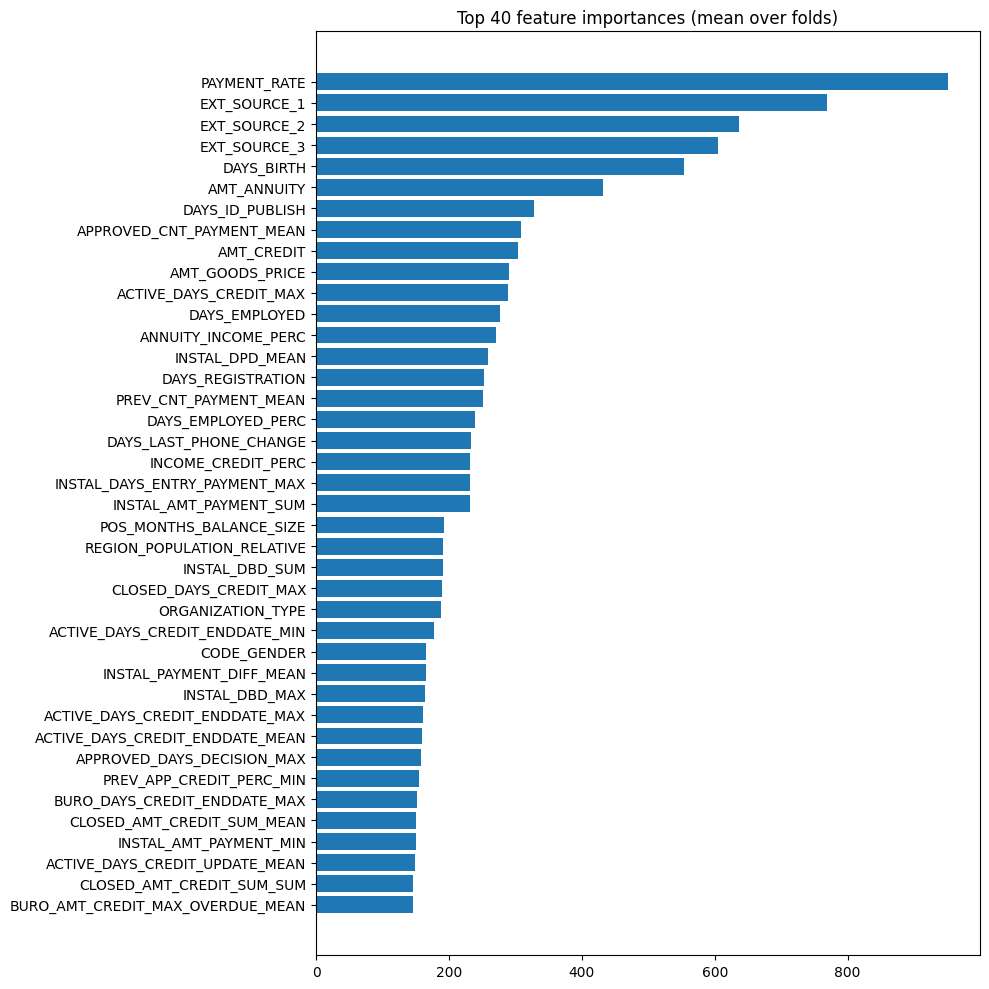

Run LightGBM with kfold - done in 2868s

PIPELINE TERMINÉ


[I 2025-12-26 01:05:24,074] A new study created in memory with name: LightGBM_BusinessCost_Optimization


Démarrage optimisation Optuna : 5 trials, 5-fold CV
Objectif : minimiser le coût métier (10*FN + 1*FP)



  0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2972]	valid_0's auc: 0.782767	valid_0's binary_logloss: 0.525589
Evaluated only: auc
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3876]	valid_0's auc: 0.788271	valid_0's binary_logloss: 0.509693
Evaluated only: auc
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3455]	valid_0's auc: 0.790654	valid_0's binary_logloss: 0.514127
Evaluated only: auc
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3565]	valid_0's auc: 0.790919	valid_0's binary_logloss: 0.516744
Evaluated only: auc
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3650]	valid_0's auc: 0.786635	valid_0's binary_logloss: 0.517504
Evaluated only: auc
[I 2025-12-26 02:12:32,729] Trial 0 finished with value: 29890.0 and parameters: {'le

In [ ]:
feat_importance = main(debug=False,run_optuna=True)

In [ ]:
!zip -r /content/mlruns.zip /content/mlruns